In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from glob import glob
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler

from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
DATASET_PATH = "/kaggle/input/datasets/vencerlanz09/agricultural-pests-image-dataset"

print("Classes:", os.listdir(DATASET_PATH))

Classes: ['beetle', 'grasshopper', 'earthworms', 'ants', 'earwig', 'snail', 'catterpillar', 'weevil', 'bees', 'moth', 'wasp', 'slug']


,Class,Count
0,beetle,416
1,grasshopper,485
2,earthworms,323
3,ants,499
4,earwig,466
5,snail,500
6,catterpillar,434
7,weevil,485
8,bees,500
9,moth,497


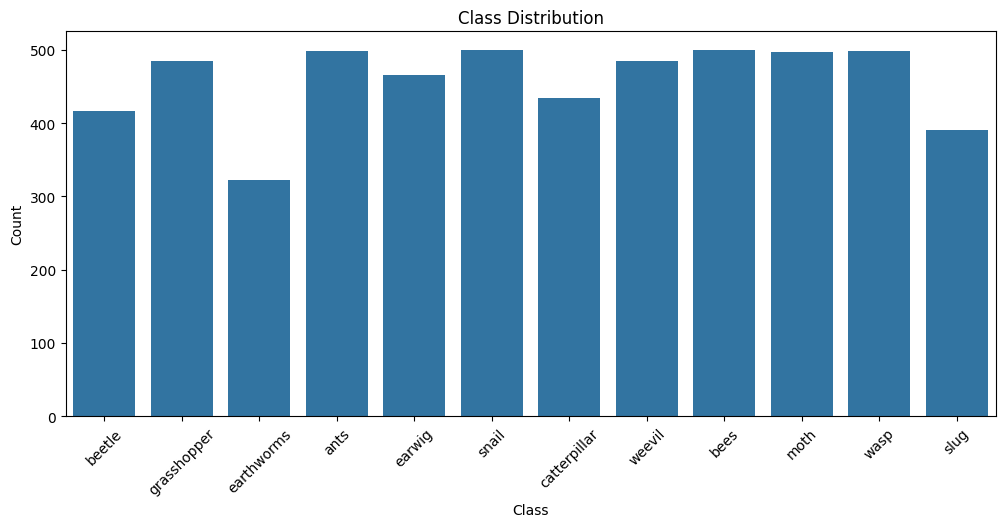

In [4]:
class_counts = {}

for cls in os.listdir(DATASET_PATH):
    class_counts[cls] = len(os.listdir(os.path.join(DATASET_PATH, cls)))

df_counts = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])
display(df_counts)

plt.figure(figsize=(12,5))
sns.barplot(data=df_counts, x='Class', y='Count')
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.savefig("/kaggle/working/class_distribution.png")
plt.show()

In [5]:
all_images = glob(DATASET_PATH + "/**/*.jpg", recursive=True)

duplicates = len(all_images) - len(set(all_images))
print("Duplicate Images Found:", duplicates)

Duplicate Images Found: 0


In [6]:
def apply_clahe(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    merged = cv2.merge((l,a,b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

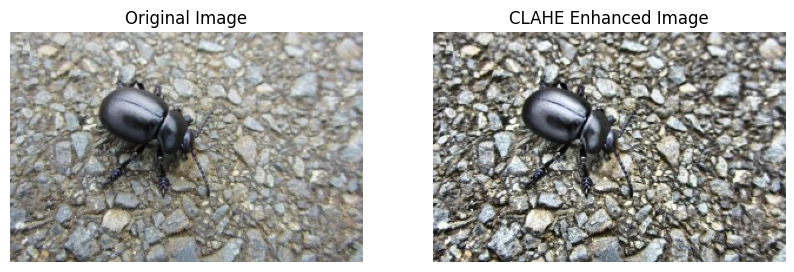

In [7]:
sample_img_path = all_images[0]
img = cv2.imread(sample_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

clahe_img = apply_clahe(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(clahe_img)
plt.title("CLAHE Enhanced Image")
plt.axis('off')

plt.savefig("/kaggle/working/clahe_visualization.png")
plt.show()

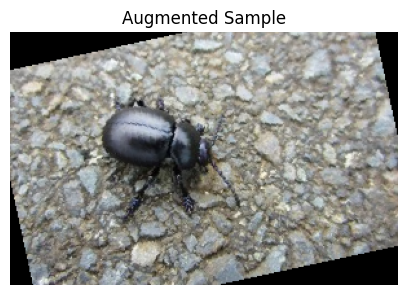

In [8]:
augment = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(),
    transforms.ToTensor()
])

augmented = augment(img)

plt.figure(figsize=(5,5))
plt.imshow(np.transpose(augmented.numpy(), (1,2,0)))
plt.title("Augmented Sample")
plt.axis('off')

plt.savefig("/kaggle/working/augmentation_preview.png")
plt.show()

In [9]:
class PestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = ImageFolder(root_dir)
        self.transform = transform
        
    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        img = np.array(img)
        img = apply_clahe(img)

        if self.transform:
            img = self.transform(img)

        return img, label


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224,224))
])

dataset = PestDataset(DATASET_PATH, transform=transform)

In [10]:
indices = list(range(len(dataset)))
labels = dataset.dataset.targets

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_loader = DataLoader(dataset, batch_size=32, sampler=SubsetRandomSampler(train_idx))
val_loader = DataLoader(dataset, batch_size=32, sampler=SubsetRandomSampler(val_idx))

In [12]:
tau = 0.5   # 🔥 CHANGE THIS VALUE FOR EXPERIMENTS (0.5, 1.0, 2.0)

In [13]:
class AdaptiveFusion(nn.Module):
    def __init__(self, dim, temperature=1.0):
        super().__init__()
        
        self.temperature = temperature
        
        self.fc1 = nn.Linear(dim*2, dim)
        self.fc2 = nn.Linear(dim, 2)

    def forward(self, cnn_feat, vit_feat):
        combined = torch.cat([cnn_feat, vit_feat], dim=1)

        x = torch.relu(self.fc1(combined))
        logits = self.fc2(x)

        weights = torch.softmax(logits / self.temperature, dim=1)

        fused = weights[:,0:1]*cnn_feat + weights[:,1:2]*vit_feat
        return fused

In [14]:
class HybridModel(nn.Module):
    def __init__(self, num_classes, tau):
        super().__init__()
        
        self.cnn = models.resnet50(pretrained=True)
        self.cnn.fc = nn.Identity()
        
        self.vit = models.vit_b_16(pretrained=True)
        self.vit.heads = nn.Identity()
        
        self.cnn_proj = nn.Linear(2048, 768)
        
        self.fusion = AdaptiveFusion(768, temperature=tau)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, x):
        cnn_feat = self.cnn(x)
        vit_feat = self.vit(x)

        cnn_feat = self.cnn_proj(cnn_feat)

        fused = self.fusion(cnn_feat, vit_feat)
        return self.classifier(fused)


model = HybridModel(len(dataset.dataset.classes), tau).cuda()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 220MB/s] 


In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)


train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(15):

    model.train()
    running_loss, correct, total = 0, 0, 0

    for imgs, labels in tqdm(train_loader):
        imgs, labels = imgs.cuda(), labels.cuda()

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    model.eval()
    val_running_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.cuda(), labels.cuda()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total

    print(f"\nEpoch {epoch+1} (tau={tau})")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

100%|██████████| 138/138 [03:59<00:00,  1.74s/it]



Epoch 1 (tau=0.5)
Train Loss: 0.9230 | Train Acc: 0.7163
Val Loss:   0.9835 | Val Acc:   0.6915


100%|██████████| 138/138 [03:55<00:00,  1.70s/it]



Epoch 2 (tau=0.5)
Train Loss: 0.5336 | Train Acc: 0.8350
Val Loss:   0.6512 | Val Acc:   0.7934


100%|██████████| 138/138 [03:55<00:00,  1.71s/it]


...


Epoch 13 (tau=0.5)
Train Loss: 0.2261 | Train Acc: 0.9365
Val Loss:   0.8546 | Val Acc:   0.7880


100%|██████████| 138/138 [03:55<00:00,  1.71s/it]



Epoch 14 (tau=0.5)
Train Loss: 0.0530 | Train Acc: 0.9834
Val Loss:   0.9541 | Val Acc:   0.7598


100%|██████████| 138/138 [03:55<00:00,  1.71s/it]



Epoch 15 (tau=0.5)
Train Loss: 0.0585 | Train Acc: 0.9800
Val Loss:   0.6200 | Val Acc:   0.8226
